# Rule-Based Regime Segmentation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Insert data-path here 
data_path = r'C:\Users\jacob\Documents\GitHub\COMP0047-Data-Science-Project\notebooks\data\master_data.csv'
df = pd.read_csv(data_path)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_col = 'GSPC'
ret_col = 'Return'

print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (8066, 27)


,Date,GSPC,VIX,SPY Volume,GDP,Core_Inflation,Unemployment,M2,Return,Return_5d,...,quarter,GDP_YoY,month,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,Regime
0,1994-01-27,477.049988,10.30,344500,10939.116,66.902,6.6,3474.9,0.008136,0.004358,...,1,0.034307,1,0.022466,0.016320,477.049988,0.000000,-0.870000,-0.860000,NaN
1,1994-01-28,478.700012,9.94,356500,10939.116,66.902,6.6,3474.9,0.003459,0.008384,...,1,0.034307,1,0.020516,0.017689,478.700012,0.000000,-0.360001,-1.150001,NaN
2,1994-01-31,481.609985,10.63,313800,10939.116,66.902,6.6,3474.9,0.006079,0.020425,...,1,0.034307,1,0.020516,0.017689,481.609985,0.000000,0.690001,-0.970000,NaN
3,1994-02-01,479.619995,10.65,303600,10939.116,67.047,6.6,3475.7,-0.004132,0.018474,...,1,0.034307,2,0.022728,0.017924,481.609985,-0.004132,0.020000,-0.730000,NaN
4,1994-02-02,482.000000,10.61,307600,10939.116,67.047,6.6,3475.7,0.004962,0.018597,...,1,0.034307,2,0.022728,0.017924,482.000000,0.000000,-0.040000,-0.560000,NaN


## Rule-Based Logic

We classify market regimes using a strategy based on Simple Moving Averages (SMA):

| Indicator | Definition |
|-----------|------------|
| **SMA 50** | 50-day Simple Moving Average of the S&P 500 price |
| **SMA 200** | 200-day Simple Moving Average of the S&P 500 price |
| **Rolling Volatility** | 21-day rolling standard deviation of daily returns |

**Regime Rules:**
- **Bull**: SMA(50) > SMA(200) — the short-term trend is above the long-term trend
- **Bear**: SMA(50) ≤ SMA(200) — the short-term trend is below the long-term trend

For the initial 200 days where the 200-day SMA is unavailable, backfill with the first observed regime.

In [ ]:
# Calculate Moving Averages for Rule-Based Logic
df['SMA_50'] = df[price_col].rolling(window=50).mean()
df['SMA_200'] = df[price_col].rolling(window=200).mean()
df['Roll_Vol_21d'] = df[ret_col].rolling(window=21).std()

# Drop NaNs from the longest rolling window (200 days) to ensure clean logic
df_clean = df.dropna(subset=['SMA_200']).copy().reset_index(drop=True)
print(f"Cleaned data shape (after dropping 200d NaNs): {df_clean.shape}")

Cleaned data shape (after dropping 200d NaNs): (7867, 30)


In [ ]:
conditions = [
    (df_clean['SMA_50'] > df_clean['SMA_200']),
    (df_clean['SMA_50'] <= df_clean['SMA_200'])
]
choices = ['bull', 'bear']

# Initialize as object to avoid dtype issues
df_clean['regime'] = pd.Series(dtype='object')
df_clean['regime'] = np.select(conditions, choices, default='unknown')

# Merge back to original dataframe
# We drop the old 'Regime' or 'regime' columns if they exist to avoid conflicts
if 'Regime' in df.columns:
    df = df.drop(columns=['Regime'])

df = df.merge(df_clean[['Date', 'regime']], on='Date', how='left')

# For the first 200 days (where SMA_200 is NaN), we can backfill with the first known regime
first_regime = df_clean['regime'].iloc[0]
df['regime'] = df['regime'].fillna(first_regime)

print("Rule-based regime mapping complete.")
print("\nRegime Counts:")
print(df['regime'].value_counts())
print("\nRegime Proportions:")
print(df['regime'].value_counts(normalize=True).round(3))

Rule-based regime mapping complete.

Regime Counts:
regime
bull    6137
bear    1929
Name: count, dtype: int64

Regime Proportions:
regime
bull    0.761
bear    0.239
Name: proportion, dtype: float64


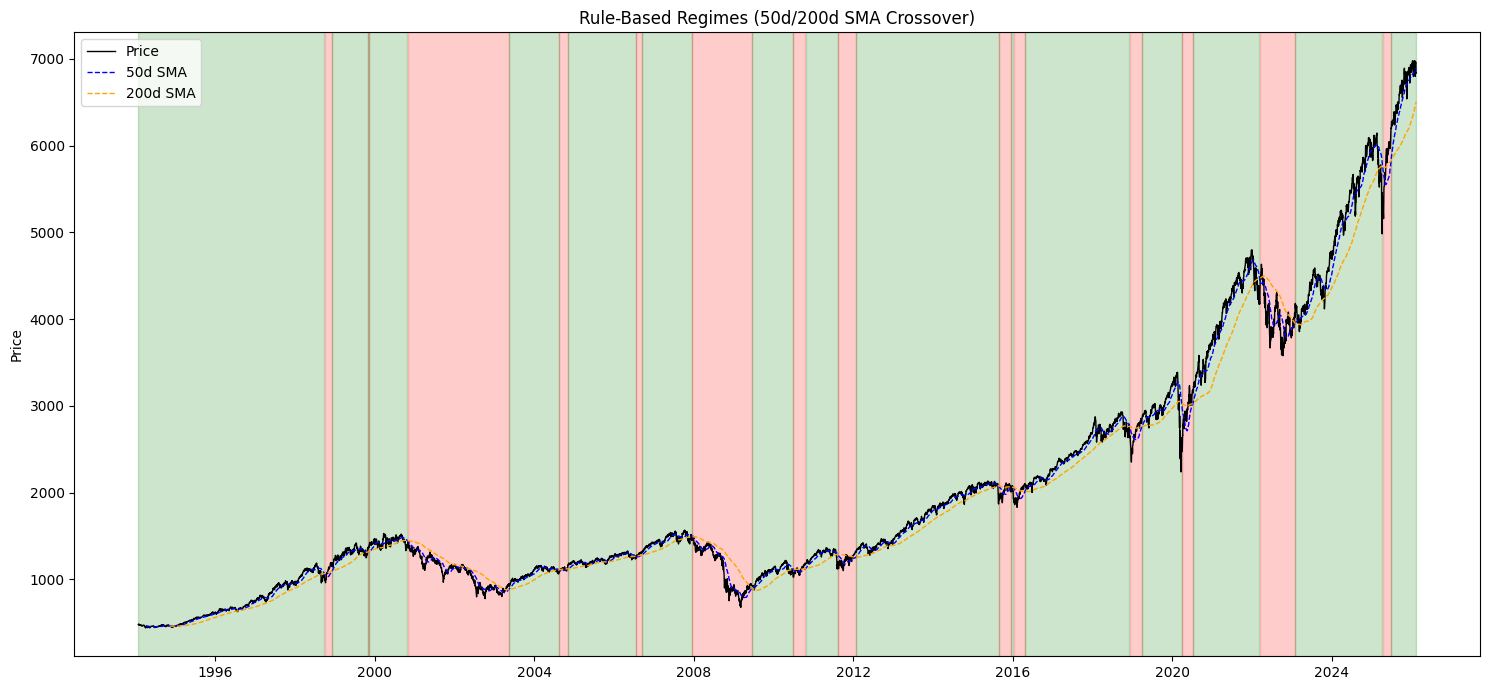

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.plot(df['Date'], df[price_col], color='black', linewidth=1, label='Price')
ax1.plot(df['Date'], df['SMA_50'], color='blue', linewidth=1, linestyle='--', label='50d SMA')
ax1.plot(df['Date'], df['SMA_200'], color='orange', linewidth=1, linestyle='--', label='200d SMA')
ax1.set_title('Rule-Based Regimes (50d/200d SMA Crossover) - [Green = Bull], [Red = Bear]')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')

# Add shading
df['regime_change'] = (df['regime'] != df['regime'].shift(1)).cumsum()
for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax1.axvspan(start_date, end_date, color=color, alpha=0.2)

plt.tight_layout()
plt.show()
df = df.drop(columns=['regime_change'])

In [ ]:
missing_regimes = df['regime'].isna().sum()
assert missing_regimes == 0, f"Error: Found {missing_regimes} missing values in 'regime' column!"
print("Validation passed: No missing values in 'regime' column.")

# write df to .csv
output_csv = r'C:\Users\jacob\Documents\GitHub\COMP0047-Data-Science-Project\notebooks\data\rule_based_labeled_dataset.csv'
df.to_csv(output_csv, index=False)
print(f"Dataset saved to {output_csv}")

Validation passed: No missing values in 'regime' column.
Dataset saved to C:\Users\jacob\Documents\GitHub\COMP0047-Data-Science-Project\notebooks\data\rule_based_labeled_dataset.csv
